<a href="https://colab.research.google.com/github/arunangshu19/PINN/blob/schrodinger/tise_ang_l3_m2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


=== Run 1/5 ===
Iter    0 PDE Loss: 1.240e+00
Iter  500 PDE Loss: 1.542e-05
Iter 1000 PDE Loss: 1.033e-03
Iter 1500 PDE Loss: 2.629e-04
Iter 2000 PDE Loss: 3.520e-07
Iter 2500 PDE Loss: 2.985e-07
Iter 3000 PDE Loss: 3.052e-07
Iter 3500 PDE Loss: 2.289e-07
Iter 4000 PDE Loss: 2.242e-07
Iter 4500 PDE Loss: 2.152e-07

=== Run 2/5 ===
Iter    0 PDE Loss: 1.797e+00
Iter  500 PDE Loss: 1.985e-06
Iter 1000 PDE Loss: 4.119e-06
Iter 1500 PDE Loss: 7.926e-07
Iter 2000 PDE Loss: 3.512e-06
Iter 2500 PDE Loss: 6.203e-07
Iter 3000 PDE Loss: 3.576e-07
Iter 3500 PDE Loss: 3.143e-07
Iter 4000 PDE Loss: 2.952e-07
Iter 4500 PDE Loss: 2.731e-07

=== Run 3/5 ===
Iter    0 PDE Loss: 2.543e+00
Iter  500 PDE Loss: 2.252e-06
Iter 1000 PDE Loss: 1.411e-06
Iter 1500 PDE Loss: 1.325e-05
Iter 2000 PDE Loss: 4.272e-06
Iter 2500 PDE Loss: 1.370e-06
Iter 3000 PDE Loss: 4.560e-07
Iter 3500 PDE Loss: 4.003e-07
Iter 4000 PDE Loss: 3.411e-07
Iter 4500 PDE Loss: 3.304e-07

=== Run 4/5 ===
Iter    0 PDE Loss: 1.125e+00
It

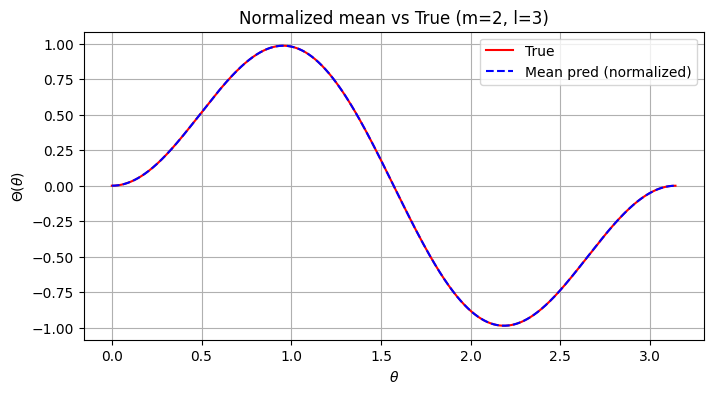

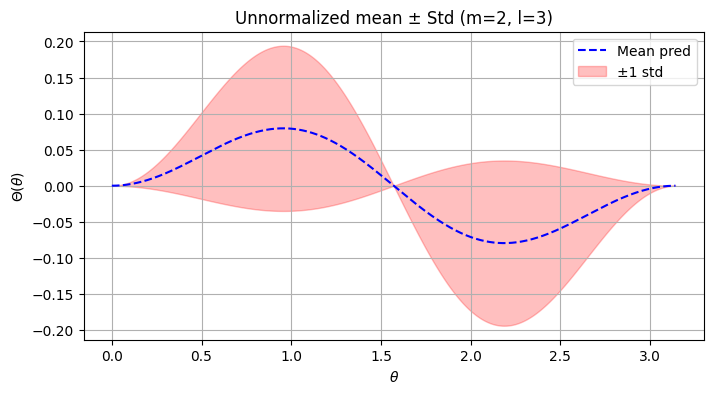

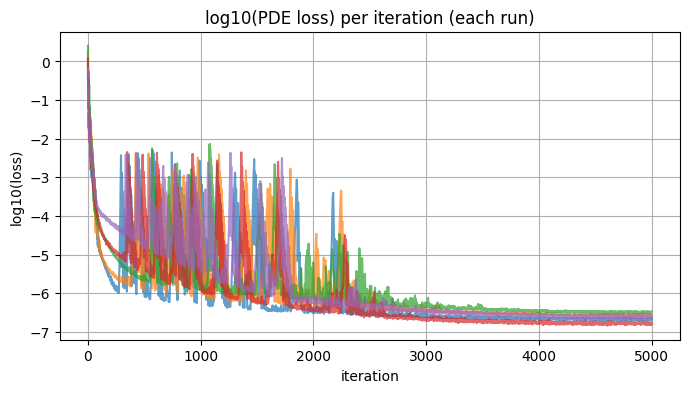

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
from scipy.special import lpmv, gamma

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === USER PARAMETERS ===
l = 3             # degree
m = 2            # order
n_points_pool = 20000
batch_size = 2048
n_iter = 5000
lr = 1e-4
clip_norm = 5.0
n_runs = 5
# ========================

# SIREN-style Network
class SIREN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.linears = nn.ModuleList()
        for i in range(len(layers)-1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        self.act_first = torch.sin
        self.act_hidden = torch.tanh

        with torch.no_grad():
            self.linears[0].weight.uniform_(-1, 1)
            for lin in self.linears[1:]:
                nn.init.xavier_uniform_(lin.weight)
                nn.init.zeros_(lin.bias)

    def forward(self, x):
        x = self.act_first(self.linears[0](x))
        for lin in self.linears[1:-1]:
            x = self.act_hidden(lin(x))
        return self.linears[-1](x)

# --- Input embedding ---
def embed_theta(theta):
    return torch.cat([torch.sin(theta), torch.cos(theta)], dim=1)

# --- Trial solution (BC enforced, no clamp) ---
def trial_solution(model, theta, m):
    return (torch.sin(theta) ** abs(m)) * model(embed_theta(theta))

# --- Angular residual (no clamp, no eps) ---
def angular_residual(model, theta, l, m):
    theta = theta.clone().requires_grad_(True)
    y = trial_solution(model, theta, m)
    dy = grad(y, theta, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    d2y = grad(dy, theta, grad_outputs=torch.ones_like(dy), create_graph=True)[0]
    sin_theta = torch.sin(theta)
    cot = torch.cos(theta) / sin_theta
    sin2 = sin_theta ** 2
    res = d2y + cot * dy + (l * (l + 1) - (m ** 2) / sin2) * y
    return res

# --- Pool of θ (avoid exact poles only) ---
def make_theta_pool(n_points):
    return np.linspace(1e-6, np.pi - 1e-6, n_points)

# --- Training ---
def train(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = SIREN([2, 256, 128, 128, 128, 1]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_iter)

    theta_pool = make_theta_pool(n_points_pool)
    theta_pool_t = torch.tensor(theta_pool, dtype=torch.float32, device=device).view(-1, 1)

    losses = []
    for itr in range(n_iter):
        idx = torch.randint(0, n_points_pool, (batch_size,), device=device)
        th_batch = theta_pool_t[idx]
        optimizer.zero_grad()
        res = angular_residual(model, th_batch, l, m)
        loss = torch.mean(res ** 2)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())
        if itr % 500 == 0:
            print(f"Iter {itr:4d} PDE Loss: {loss.item():.3e}")

    # LBFGS finetune (optional)
    theta_full = theta_pool_t.clone().detach()
    theta_full.requires_grad_(True)

    def closure():
        optimizer_lbfgs.zero_grad()
        res_full = angular_residual(model, theta_full, l, m)
        loss_full = torch.mean(res_full ** 2)
        loss_full.backward()
        return loss_full

    optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.5, max_iter=200, tolerance_grad=1e-8)
    optimizer_lbfgs.step(closure)

    return model, losses, theta_pool

# --- Evaluate model ---
def evaluate(model, theta_grid):
    theta_t = torch.tensor(theta_grid, dtype=torch.float32, device=device).view(-1, 1)
    with torch.no_grad():
        pred = trial_solution(model, theta_t, m).cpu().numpy().flatten()
    return pred

# --- Normalization (for plotting) ---
def sin_weighted_norm(a, theta_grid):
    w = np.sin(theta_grid)
    return np.sqrt(np.trapz(a ** 2 * w, theta_grid))

# --- Plotting ---
def plot_aggregates(theta_grid, preds_list, all_losses):
    true = lpmv(abs(m), l, np.cos(theta_grid))
    if m < 0:
        factor = (-1) ** abs(m) * (gamma(l - abs(m) + 1) / gamma(l + abs(m) + 1))
        true = factor * true

    true_norm = true / (sin_weighted_norm(true, theta_grid) + 1e-16)

    A = np.stack(preds_list, axis=0)
    mean_preds = np.mean(A, axis=0)
    std_preds = np.std(A, axis=0)

    mean_norm = mean_preds / (sin_weighted_norm(mean_preds, theta_grid) + 1e-16)

    plt.figure(figsize=(8, 4))
    plt.plot(theta_grid, true_norm, 'r-', label='True')
    plt.plot(theta_grid, mean_norm, 'b--', label='Mean pred (normalized)')
    plt.title(f'Normalized mean vs True (m={m}, l={l})')
    plt.xlabel(r'$\theta$'); plt.ylabel(r'$\Theta(\theta)$')
    plt.legend(); plt.grid(True); plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(theta_grid, mean_preds, 'b--', label='Mean pred')
    plt.fill_between(theta_grid, mean_preds - std_preds, mean_preds + std_preds,
                     color='red', alpha=0.25, label='±1 std')
    plt.title(f'Unnormalized mean ± Std (m={m}, l={l})')
    plt.xlabel(r'$\theta$'); plt.ylabel(r'$\Theta(\theta)$')
    plt.legend(); plt.grid(True); plt.show()

    plt.figure(figsize=(8, 4))
    for run_losses in all_losses:
        arr = np.array(run_losses)
        plt.plot(np.log10(np.maximum(arr, 1e-16)), alpha=0.7)
    plt.title('log10(PDE loss) per iteration (each run)')
    plt.xlabel('iteration'); plt.ylabel('log10(loss)')
    plt.grid(True); plt.show()

# --- Main loop ---
all_preds, all_losses = [], []
theta_grid_global = make_theta_pool(n_points_pool)

for run in range(n_runs):
    print(f"\n=== Run {run+1}/{n_runs} ===")
    model, losses, pool = train(seed=run)
    pred = evaluate(model, pool)
    all_preds.append(pred)
    all_losses.append(losses)

plot_aggregates(pool, all_preds, all_losses)
